In [3]:
import pandas as pd
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

## Make exported plots' text seen as text in Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sns.set_theme(style="white")

print(pd.__version__)
print(sns.__version__)
print(matplotlib.__version__)

2.2.1
0.13.2
3.8.3


In [5]:
input_csv_dir = r"C:\Data\ER_Radial_Interpolation_Ecad-mutants\002_Results\IntensityMeasurements"
output_csv_dir = r"C:\Data\ER_Radial_Interpolation_Ecad-mutants"

output_csv_dir_exists = os.path.exists(output_csv_dir)

if not output_csv_dir_exists:
    os.makedirs(output_csv_dir)

In [6]:
pal = sns.color_palette("colorblind")
pal

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [7]:
print(pal.as_hex())

palette = {"E/Pcad KO"                : "#d55e00",
           "E/Pcad KO+Ecad-deltaBCBS" : "#cc78bc",
           "E/Pcad KO+Ecad-GGG"       : "#56b4e9",
           "E/Pcad KO+Ecad-WT"        : "#029e73",
           "A431"                     : "#0173b2",
          }

['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


In [8]:
def ProcessDF(df):
    
    # Example filename EPcadKO+ER-StayGold_ER+WGA_001_R1_cell-001.tif_C1_Intensity.csv
    
    # Split file name at .tif which gives you two file names, one before and one after the .tif_
    # 'split1' is the file name before '.tif_'
    # 'split2' is the file name after '.tif_'
    df[["split1", "split2"]] = df["Label"].str.split(".tif_", expand = True)
    
    #After splitting file name at .tif, split the first file name ("Label") at "_cell-" and assign it as 'cell' for the cell line name
    #split3 is the cell line name now, which is from the beginning to '_cell-'
    df[["split3", "cell"]] = df["split1"][0].split("_cell-")
    
    #Assign 'channel' to the channel number in the 'split2' file (which is the file name after '.tif_'); start=1, stop=2 gives the number after the letter 'C'
    df["channel"] = df["split2"].str.slice(start = 1, stop=2)
    
    #Assign channel name to each channel number
    df.loc[df["channel"] == "1", "channel_name"] = "ER"
    df.loc[df["channel"] == "2", "channel_name"] = "WGA"
    df.loc[df["channel"] == "3", "channel_name"] = "Ecad"
    
    #Assign cell line name from beginning to right before image name '_###' in the split3.
    #This will give the cell line plus the channels.
    #You can later replace the cell line with the channel name with just the cell line (see below)
    df["cell_line"] = df["split3"].str.slice(start = 0, stop = -7)
    
    #Assign image name to split3 (the file name from beginning to _cell-)
    
    df["image"] = df["split3"].str.slice(start=-6, stop=-3)
    
    #Assign replicate number to the split3. 
    df["Rep"] = df["split3"].str.slice(start=-1)
    df.drop(columns = ["split1", "split2", "split3"], inplace = True)
    
    
    return df

input_CSVs = os.listdir(input_csv_dir)

df_concat = pd.DataFrame()

for f in input_CSVs:
    f_path = os.path.join(input_csv_dir, f)
    df_temp = pd.read_csv(f_path, usecols = ["Label", "Area", "Mean", "IntDen", "RawIntDen", "Slice"])
    df_temp["Label"] = f
    df_processed = ProcessDF(df_temp)
    df_concat = pd.concat([df_concat, df_processed])

In [9]:
df = df_concat
df

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,66.307,857.943,56887.739,13464553.0,1,001,1,ER,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,001,2
1,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.911,947.951,5603.128,1326184.0,2,001,1,ER,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,001,2
2,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.395,954.659,5150.698,1219100.0,3,001,1,ER,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,001,2
3,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.467,952.152,5205.559,1232085.0,4,001,1,ER,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,001,2
4,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.801,928.997,5389.043,1275513.0,5,001,1,ER,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,001,2
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,12.730,83.212,1059.279,250717.0,20,001,2,WGA,EPcadKO+ER-StayGold_ER+WGA,011,1
20,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,13.537,85.782,1161.216,274844.0,21,001,2,WGA,EPcadKO+ER-StayGold_ER+WGA,011,1
21,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.090,88.842,1251.817,296288.0,22,001,2,WGA,EPcadKO+ER-StayGold_ER+WGA,011,1
22,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.500,91.723,1330.000,314793.0,23,001,2,WGA,EPcadKO+ER-StayGold_ER+WGA,011,1


In [10]:
df["cell_line"].unique()

array(['EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold+Ecad-GGG-RFP_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold+Ecad-WT-RFP_ER+WGA+Ecad',
       'EPcadKO+ER-StayGold_ER+WGA'], dtype=object)

In [11]:
df["cell_line"] = df["cell_line"].replace({"EPcadKO+ER-StayGold_ER+WGA"                         : "E/Pcad KO",
                                           "EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+Ecad" : "E/Pcad KO+Ecad-deltaBCBS",
                                           "EPcadKO+ER-StayGold+Ecad-GGG-RFP_ER+WGA+Ecad"       : "E/Pcad KO+Ecad-GGG",
                                           "EPcadKO+ER-StayGold+Ecad-WT-RFP_ER+WGA+Ecad"        : "E/Pcad KO+Ecad-WT"  
                                          }
                                         )

In [12]:
df_ER = df.loc[df["channel_name"] == "ER"]
df_ER

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,66.307,857.943,56887.739,13464553.0,1,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
1,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.911,947.951,5603.128,1326184.0,2,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
2,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.395,954.659,5150.698,1219100.0,3,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
3,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.467,952.152,5205.559,1232085.0,4,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
4,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.801,928.997,5389.043,1275513.0,5,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,12.730,115.387,1468.868,347661.0,20,001,1,ER,E/Pcad KO,011,1
20,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,13.537,100.222,1356.698,321112.0,21,001,1,ER,E/Pcad KO,011,1
21,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.090,88.319,1244.453,294545.0,22,001,1,ER,E/Pcad KO,011,1
22,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.500,76.304,1106.422,261875.0,23,001,1,ER,E/Pcad KO,011,1


In [13]:
df_ER.loc[df_ER["Slice"] == 2]["Mean"]

1     947.951
1    1737.434
1    1177.842
1    1114.035
1    1694.315
       ...   
1     240.759
1     252.194
1     138.641
1     145.217
1     353.444
Name: Mean, Length: 153, dtype: float64

In [14]:
mean_list = list()
cell_line_list = list()
cell_list = list()
image_list = list()
rep_list = list()

for key, grp in df_ER.groupby(["cell_line", "cell", "image","Rep"])["Mean"]:
    (cell_line_temp, cell_temp, image_temp, rep_temp) = key
    cell_line_list.append(cell_line_temp)
    cell_list.append(cell_temp)
    image_list.append(image_temp)
    rep_list.append(rep_temp)
    
    
    # The first (index 0) measurement is the nucleus,
    # so we want the second measurement (index 1) 
    mean_list.append(grp / grp.iloc[1])
foo = pd.DataFrame(list(zip(cell_line_list, cell_list, image_list, rep_list, mean_list)),
                  columns = ["cell_line", "cell", "image", "Rep", "Normalized Mean"]
                  )



In [15]:
foo = foo.explode("Normalized Mean", ignore_index=True)
foo

,cell_line,cell,image,Rep,Normalized Mean
0,E/Pcad KO,001,001,1,0.947685
1,E/Pcad KO,001,001,1,1.0
2,E/Pcad KO,001,001,1,1.006266
3,E/Pcad KO,001,001,1,0.972754
4,E/Pcad KO,001,001,1,0.911923
...,...,...,...,...,...
3667,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.381885
3668,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.348115
3669,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.322705
3670,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.302264


In [16]:
foo["Slice"] = foo.groupby(["cell_line", "cell", "image", "Rep"]).cumcount()+1
foo

,cell_line,cell,image,Rep,Normalized Mean,Slice
0,E/Pcad KO,001,001,1,0.947685,1
1,E/Pcad KO,001,001,1,1.0,2
2,E/Pcad KO,001,001,1,1.006266,3
3,E/Pcad KO,001,001,1,0.972754,4
4,E/Pcad KO,001,001,1,0.911923,5
...,...,...,...,...,...,...
3667,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.381885,20
3668,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.348115,21
3669,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.322705,22
3670,E/Pcad KO+Ecad-deltaBCBS,004,006,3,0.302264,23


In [17]:
foo.to_csv(output_csv_dir + "" + "2025-03-28_normalized_ER_rings-to-second-ring.csv", index=False)

In [18]:
def makeNormalizedMeanLinePlot(data, output_dir, want_legend=True):
    sns.set_theme(style="white", palette=None)
    sns.set(rc = {'figure.figsize':(20,10)})
    sns.set(font_scale=2.25)
    b = sns.lineplot(data = foo,
                     x = "Slice",
                     y = "Normalized Mean",
                     hue = "cell_line",
                     markers = True,
                     dashes = False,
                     linewidth = 1,
                     legend=want_legend,
                    )
    (b.set(xlim=(1, 24),
           xticks=[4, 20],
          )
    )
    b.set_xticklabels(["Perinuclear", "Peripheral"])
    plt.ylabel("Normalized ER Mean Intensity")
    plt.xlim(2,24)
    plt.ylim(0, 1.1)
    plt.xlabel("")
     #.set_ylabels("Normalized Mean Intensity")
     #.set_xlabels("Ring #")


    plt.savefig(output_csv_dir + "legend" + str(want_legend) + "_plot_lines.png", bbox_inches = "tight")
    plt.savefig(output_csv_dir + "legend" + str(want_legend) + "_plot_lines.pdf", bbox_inches = "tight")
    plt.clf()

In [19]:
makeNormalizedMeanLinePlot(foo, output_csv_dir, want_legend=False)
makeNormalizedMeanLinePlot(foo, output_csv_dir, want_legend=True)

<Figure size 2000x1000 with 0 Axes>

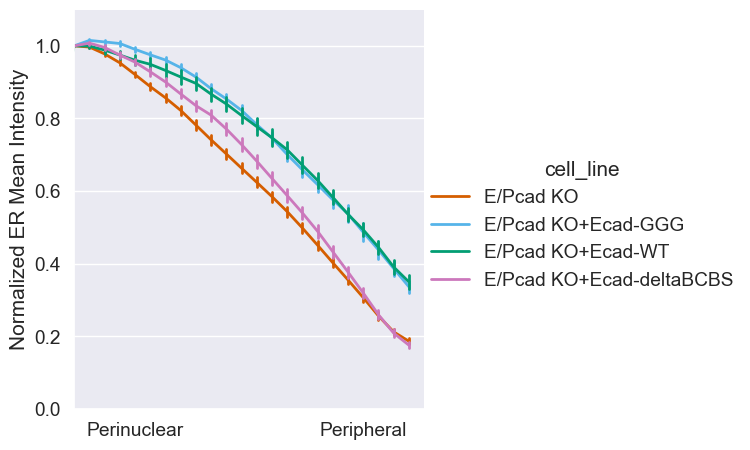

In [20]:
sns.set_theme(style="white")
sns.set(rc = {'figure.figsize':(20,10)})
sns.set(font_scale=1.25)

c = sns.catplot(
    data = foo,
    x = "Slice",
    y = "Normalized Mean",
    hue = "cell_line",
    errorbar = "se", 
    kind="point",
    fillstyle="none",
    linewidth = 2,
    #alpha=0.7,
    marker=None,
    #linestyle="dashed",
    palette=palette,

)
#sns.move_legend(c, "lower left", 
                #bbox_to_anchor=(.5, 1),
#                title=None)
c.set(xlim=(1, 24), 
      #xticks=[0, 4, 8, 12, 16, 20, 24])
       xticks=[5, 20],
     )
#c.set_xticklabels([0, 4, 8, 12, 16, 20, 24])
c.set_xticklabels(["Perinuclear", "Peripheral"])

#c.ax.legend(loc=1)
#plt.legend(title = "Cell line", 
#           loc = "lower left",
#          frameon=False)
plt.ylabel("Normalized ER Mean Intensity")
#plt.xlabel("Relative radial position")
plt.xlabel("")
plt.xlim(1,24)
plt.ylim(0, 1.1)

plt.savefig(output_csv_dir + "" +"plot_lineplot-with-markers.png", bbox_inches = "tight", dpi= 300)
plt.savefig(output_csv_dir + "" + "plot_lineplot-with-markers.pdf", bbox_inches = "tight", dpi= 300)

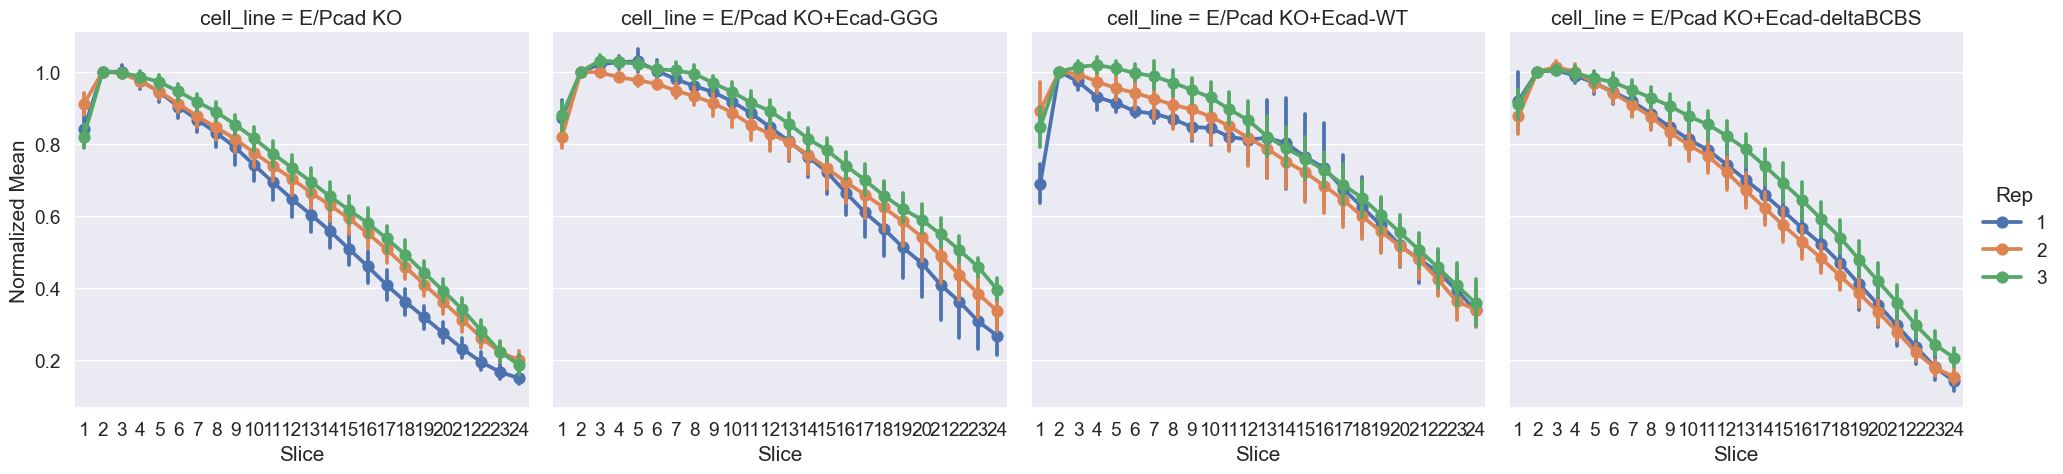

In [21]:
sharp = sns.catplot(foo,
                    x = "Slice",
                    y = "Normalized Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    #row = "Rep"
                   )

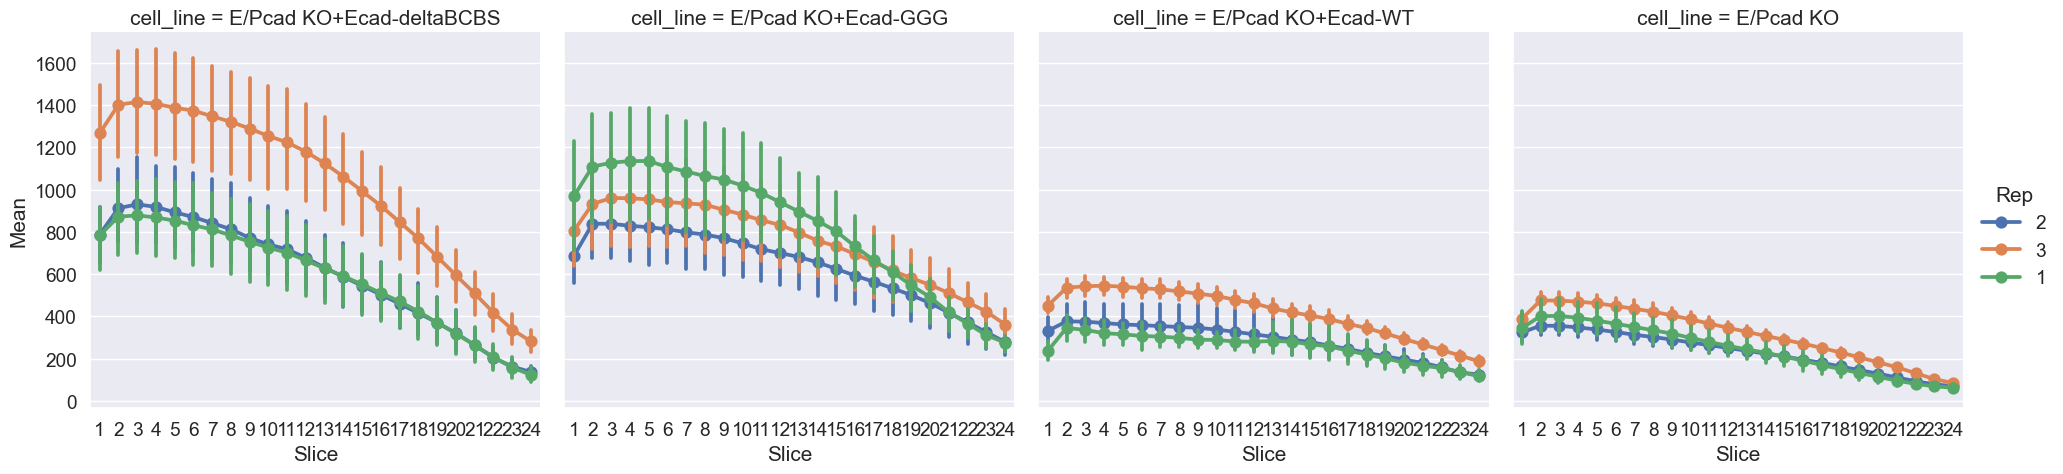

In [22]:
sharp = sns.catplot(df_ER,
                    x = "Slice",
                    y = "Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    #row = "Rep"
                   )

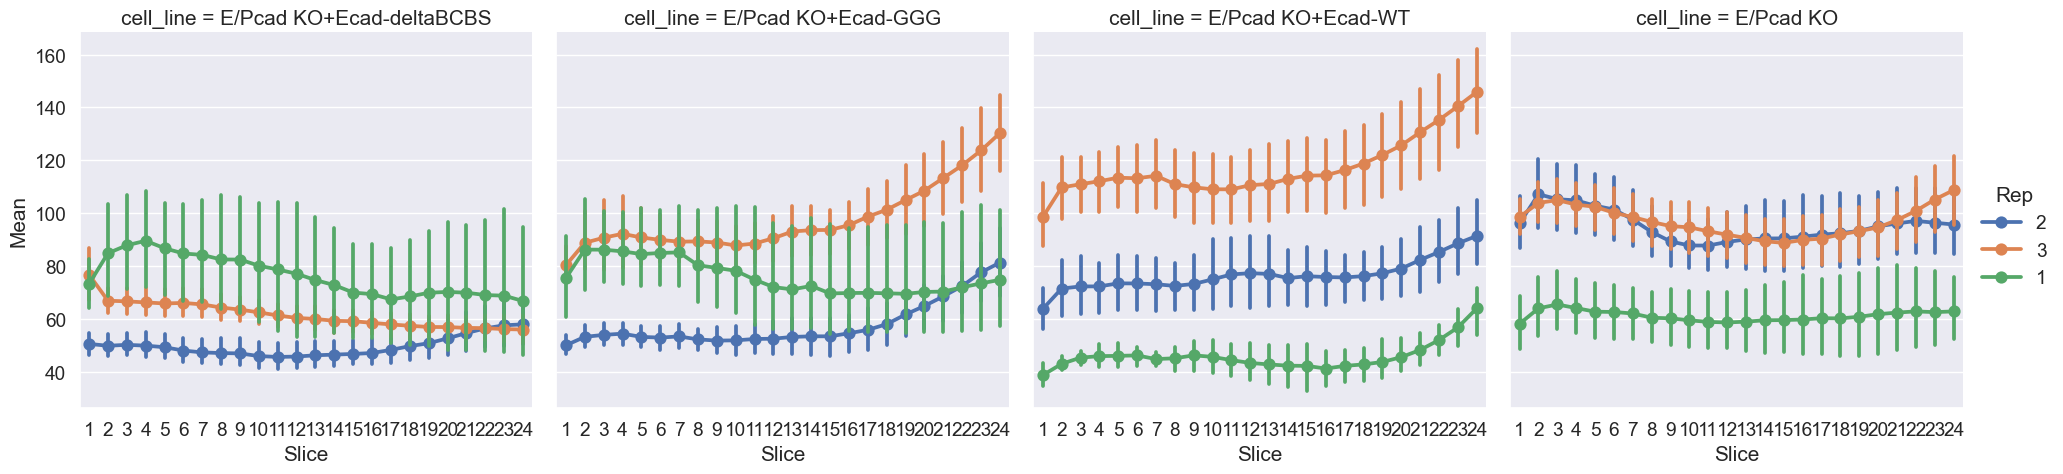

In [23]:
df_WGA = df.loc[df["channel_name"] == "WGA"]

sharp = sns.catplot(df_WGA,
                    x = "Slice",
                    y = "Mean",
                    hue = "Rep",
                    col = "cell_line",
                    kind = "point",
                    #row = "Rep"
                   )

In [24]:
#df_ER.groupby(["cell_line", "cell", "image"])[["Mean"]].nth(1)

In [25]:
non_nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].tail(23)
non_nuclear_ER_rings

,Mean
1,947.951
2,954.659
3,952.152
4,928.997
5,889.164
...,...
19,115.387
20,100.222
21,88.319
22,76.304


In [26]:
nuclear_ER_rings = df_ER.groupby(["cell_line", "cell", "image", "Rep"])[["Mean"]].nth(1)
nuclear_ER_rings


,Mean
1,947.951
1,1737.434
1,1177.842
1,1114.035
1,1694.315
...,...
1,240.759
1,252.194
1,138.641
1,145.217


In [27]:
non_nuclear_ER_rings = df_ER.loc[(df_ER["Slice"] > 1)]
non_nuclear_ER_rings

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.911,947.951,5603.128,1326184.0,2,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
2,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.395,954.659,5150.698,1219100.0,3,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
3,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.467,952.152,5205.559,1232085.0,4,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
4,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.801,928.997,5389.043,1275513.0,5,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
5,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,6.169,889.164,5484.807,1298179.0,6,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
...,...,...,...,...,...,...,...,...,...,...,...,...
19,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,12.730,115.387,1468.868,347661.0,20,001,1,ER,E/Pcad KO,011,1
20,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,13.537,100.222,1356.698,321112.0,21,001,1,ER,E/Pcad KO,011,1
21,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.090,88.319,1244.453,294545.0,22,001,1,ER,E/Pcad KO,011,1
22,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.500,76.304,1106.422,261875.0,23,001,1,ER,E/Pcad KO,011,1


In [28]:
df_ER.loc[(df_ER["Slice"] == 1)]

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,66.307,857.943,56887.739,13464553.0,1,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,126.598,1436.269,181828.710,43036379.0,1,002,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,76.443,856.424,65467.574,15495283.0,1,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,3
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,102.769,1045.301,107424.458,25425906.0,1,002,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,3
0,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,124.874,1254.170,156613.381,37068254.0,1,003,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,3
...,...,...,...,...,...,...,...,...,...,...,...,...
0,EPcadKO+ER-StayGold_ER+WGA_008_R2_cell-002.tif...,178.451,201.450,35949.027,8508645.0,1,002,1,ER,E/Pcad KO,008,2
0,EPcadKO+ER-StayGold_ER+WGA_008_R2_cell-003.tif...,181.629,225.935,41036.333,9712741.0,1,003,1,ER,E/Pcad KO,008,2
0,EPcadKO+ER-StayGold_ER+WGA_008_R2_cell-004.tif...,161.826,132.113,21379.342,5060199.0,1,004,1,ER,E/Pcad KO,008,2
0,EPcadKO+ER-StayGold_ER+WGA_008_R2_cell-005.tif...,191.101,117.355,22426.664,5308086.0,1,005,1,ER,E/Pcad KO,008,2


In [29]:
scaled_non_nuclear_ER_rings = non_nuclear_ER_rings / df_ER.loc[(df_ER["Slice"] == 1)]
scaled_non_nuclear_ER_rings

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
foo = df_ER.loc[(df_ER["Slice"] > 1) & (df_ER["Slice"] < 24)]
foo

,Label,Area,Mean,IntDen,RawIntDen,Slice,cell,channel,channel_name,cell_line,image,Rep
1,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.911,947.951,5603.128,1326184.0,2,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
2,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.395,954.659,5150.698,1219100.0,3,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
3,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.467,952.152,5205.559,1232085.0,4,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
4,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,5.801,928.997,5389.043,1275513.0,5,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
5,EPcadKO+ER-StayGold+Ecad-deltaBCBS-RFP_ER+WGA+...,6.169,889.164,5484.807,1298179.0,6,001,1,ER,E/Pcad KO+Ecad-deltaBCBS,001,2
...,...,...,...,...,...,...,...,...,...,...,...,...
18,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,12.430,133.445,1658.714,392595.0,19,001,1,ER,E/Pcad KO,011,1
19,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,12.730,115.387,1468.868,347661.0,20,001,1,ER,E/Pcad KO,011,1
20,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,13.537,100.222,1356.698,321112.0,21,001,1,ER,E/Pcad KO,011,1
21,EPcadKO+ER-StayGold_ER+WGA_011_R1_cell-001.tif...,14.090,88.319,1244.453,294545.0,22,001,1,ER,E/Pcad KO,011,1


In [31]:
inner = foo[["cell_line", "Mean"]].groupby("cell_line").mean()
inner

,Mean
cell_line,
E/Pcad KO,267.864042
E/Pcad KO+Ecad-GGG,745.316858
E/Pcad KO+Ecad-WT,353.020091
E/Pcad KO+Ecad-deltaBCBS,800.415077


In [64]:
inner_by_rep = foo[["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
inner_by_rep

Mean
cell_line                Rep             
E/Pcad KO                1     248.304580
                         2     235.597498
                         3     324.772882
E/Pcad KO+Ecad-GGG       1     838.321565
                         2     653.915551
                         3     766.764210
E/Pcad KO+Ecad-WT        1     261.503409
                         2     288.885557
                         3     426.282008
E/Pcad KO+Ecad-deltaBCBS 1     601.329195
                         2     615.563479
                         3    1038.596716

In [63]:
outer_by_rep = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
outer_by_rep

Mean
cell_line                Rep            
E/Pcad KO                1     62.019750
                         2     70.019500
                         3     84.813950
E/Pcad KO+Ecad-GGG       1    275.722286
                         2    278.522000
                         3    361.249000
E/Pcad KO+Ecad-WT        1    116.639250
                         2    124.356625
                         3    187.058500
E/Pcad KO+Ecad-deltaBCBS 1    123.447400
                         2    136.576933
                         3    281.322650

In [ ]:
# Outer by cell, image, rep, cell line !!!
outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
outer_by_cell
outer_by_cell.to_csv("outer-by-cell.csv", index=False)


In [36]:
#outer = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Mean"]].groupby("cell_line").mean()
#outer

In [65]:
perinuclear_by_rep = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Mean", "Rep"]].groupby(["cell_line", "Rep"]).mean()
perinuclear_by_rep


Mean
cell_line                Rep             
E/Pcad KO                1     401.774667
                         2     355.893643
                         3     475.558900
E/Pcad KO+Ecad-GGG       1    1108.744857
                         2     838.177111
                         3     931.770500
E/Pcad KO+Ecad-WT        1     345.621000
                         2     376.597875
                         3     535.521750
E/Pcad KO+Ecad-deltaBCBS 1     871.683400
                         2     911.983933
                         3    1401.556450

In [ ]:
# Perinuclear by cell, image, rep, cell line
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell
perinuclear_by_cell.to_csv("perinuclear-by-cell.csv", index=False)

In [69]:
# Outer to perinuclear grouped by cell, image, replicate, cell line

# Extract the relevant data frames
outer_by_cell = df_ER.loc[(df_ER["Slice"] == 24)][["cell_line", "Rep", "image", "cell", "Mean"]]
perinuclear_by_cell = df_ER.loc[(df_ER["Slice"] == 2)][["cell_line", "Rep", "image", "cell", "Mean"]]

# Merge on 'cell_line', 'cell', and 'Rep' to align exact replicates
merged_df = pd.merge(outer_by_cell, perinuclear_by_cell, on=["cell_line", "Rep", "image", "cell"], suffixes=("_outer", "_perinuclear"))

# Perform element-wise division of the 'Mean' values
merged_df["Mean_ratio"] = merged_df["Mean_outer"] / merged_df["Mean_perinuclear"]

# Sort the merged DataFrame by 'cell_line' and 'Rep'
merged_df_sorted = merged_df.sort_values(by=["cell_line", "Rep"])

print(merged_df_sorted)
merged_df_sorted.to_csv("ratio-outer-to-perinuclear-by-cell.csv", index=False)


#print(merged_df)
#merged_df.to_csv("ratio-outer-to-perinuclear-by-cell.csv", index=False)

                    cell_line Rep image cell  Mean_outer  Mean_perinuclear  \
93                  E/Pcad KO   1   001  001      70.389           563.644   
94                  E/Pcad KO   1   001  002      94.789           629.115   
101                 E/Pcad KO   1   002  001     100.367           606.566   
119                 E/Pcad KO   1   005  001      31.254           276.177   
120                 E/Pcad KO   1   005  002      29.011           212.447   
..                        ...  ..   ...  ...         ...               ...   
29   E/Pcad KO+Ecad-deltaBCBS   3   006  002     138.403           704.183   
30   E/Pcad KO+Ecad-deltaBCBS   3   006  003     131.623           552.661   
31   E/Pcad KO+Ecad-deltaBCBS   3   006  004     181.785           605.766   
33   E/Pcad KO+Ecad-deltaBCBS   3   007  001     154.907          1079.287   
34   E/Pcad KO+Ecad-deltaBCBS   3   007  002     169.971          1475.814   

     Mean_ratio  
93     0.124882  
94     0.150670  
101    0.

In [66]:
outer_to_inner_by_rep = outer_by_rep["Mean"] / inner_by_rep["Mean"]
outer_to_inner_by_rep

cell_line                 Rep
E/Pcad KO                 1      0.249773
                          2      0.297200
                          3      0.261148
E/Pcad KO+Ecad-GGG        1      0.328898
                          2      0.425930
                          3      0.471134
E/Pcad KO+Ecad-WT         1      0.446033
                          2      0.430470
                          3      0.438814
E/Pcad KO+Ecad-deltaBCBS  1      0.205291
                          2      0.221873
                          3      0.270868
Name: Mean, dtype: float64

In [67]:
outer_to_perinuclear_by_rep = outer_by_rep["Mean"] / perinuclear_by_rep["Mean"]
outer_to_perinuclear_by_rep

cell_line                 Rep
E/Pcad KO                 1      0.154365
                          2      0.196743
                          3      0.178346
E/Pcad KO+Ecad-GGG        1      0.248680
                          2      0.332295
                          3      0.387702
E/Pcad KO+Ecad-WT         1      0.337477
                          2      0.330211
                          3      0.349301
E/Pcad KO+Ecad-deltaBCBS  1      0.141620
                          2      0.149758
                          3      0.200722
Name: Mean, dtype: float64

In [ ]:
#outer_to_perinuclear_by_cell = outer_by_cell / perinuclear_by_cell
#outer_to_perinuclear_by_cell
#outer_to_perinuclear_by_cell.to_csv("test1.csv", index=False)

,cell_line,cell,Mean,Rep
1,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
...,...,...,...,...
23,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN


In [ ]:
outer_to_inner.to_csv(output_csv_dir + "" + "outer-to-inner-ratio.csv", index=False)
outer_to_perinuclear.to_csv(output_csv_dir + "" + "outer-to-perinuclear-ratio.csv", index=False)

In [ ]:
df.to_csv(output_csv_dir + "2024-03-28_merged-results.csv", index=False)